# 04 · Modelado (§4.1 desbalance · §4.3 búsqueda, ventanas y ensembles)

Fase **greedy**: cada decisión se toma con los 4 bloques de validación temporal del pool de desarrollo
(`02_particion`) y queda fija antes de la siguiente. El OOT no se toca.

1. **Desbalance (§4.1)**: pesos de clase vs sin ponderar vs submuestreo aleatorio vs SMOTE, con el XGBoost de
   referencia de `03` y las 6 variables seleccionadas. Se conserva la mejor opción.
2. **Optuna (§4.3)**: LogReg, RF, XGBoost, LightGBM y CatBoost × {6, 42} variables, **idéntico presupuesto**
   (`N_TRIALS` por estudio), objetivo = AUC medio de los 4 bloques, peso de clase dentro del espacio de búsqueda.
3. **Conjunto de variables por algoritmo**: 6 vs 42 con el criterio de selección.
4. **Ventanas de entrenamiento**: 24 / 36 / 48 meses / toda la historia, con los hiperparámetros ya fijados.
5. **Ensembles por promedio** de probabilidades de los mejores candidatos individuales.

**Criterio de selección (§4.3)**: AUC medio de los 4 bloques; empate (diferencia ≤ `TOL_AUC`) → Top Decile Lift
mensual; empate (≤ `TOL_LIFT`) → el modelo más simple (menos miembros, luego menos variables).
La búsqueda vive en `tuning.py`; los estudios se persisten en `optuna.db` (reanudable, no versionado).

In [1]:
import sys, json, time, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from src import datos, particion, evaluacion
import tuning
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

df = datos.load()
FEATS = datos.features(df)
SEL = json.loads((Path.cwd().parent / "03_variables/variables_seleccionadas.json").read_text())["seleccionadas"]
CONJUNTOS = {"6": SEL, "42": FEATS}
dev_mask, _ = particion.oot_split(df.mes_rank)
dev = df[dev_mask].reset_index(drop=True)          # el OOT no se toca en esta fase
folds = particion.temporal_folds(dev.mes_rank)

N_TRIALS = 100
TOL_AUC, TOL_LIFT = 0.001, 0.02

def ref_model(y, w=None):   # mismo XGBoost de referencia que en 03
    return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                         scale_pos_weight=evaluacion.scale_pos_weight(y) if w is None else w,
                         tree_method="hist", n_jobs=tuning.N_JOBS, random_state=42, verbosity=0)

def fila(nombre, r, **extra):
    return {"config": nombre, **{f"auc_b{i+1}": a for i, a in enumerate(r["aucs"])},
            "auc": round(r["auc"], 4), "std": round(r["std"], 4), "lift10": round(r["lift10"], 3), **extra}

def elegir(tabla):
    # AUC medio → (empate) lift top-10 % → (empate) el más simple: menos miembros, luego menos variables
    t = tabla[tabla.auc >= tabla.auc.max() - TOL_AUC]
    t = t[t.lift10 >= t.lift10.max() - TOL_LIFT]
    simple = [c for c in ("n_miembros", "n_vars") if c in t.columns]
    return t.sort_values(simple + ["auc"], ascending=[True] * len(simple) + [False]).index[0]

print(f"desarrollo: {len(dev):,} filas | conjuntos: 6 y {len(FEATS)} variables | {len(folds)} bloques | "
      f"{N_TRIALS} trials por estudio")

desarrollo: 29,183 filas | conjuntos: 6 y 42 variables | 4 bloques | 100 trials por estudio


## 1 · Desbalance (§4.1)

Cuatro estrategias con el mismo modelo de referencia y las 6 variables. El remuestreo (submuestreo / SMOTE) va
dentro de un pipeline de `imblearn`, así solo se aplica al entrenamiento de cada bloque.

In [2]:
def con_sampler(cls):
    return lambda y: ImbPipeline([("sampler", cls(random_state=42)), ("clf", ref_model(y, w=1.0))])

ESTRATEGIAS = {"pesos de clase": ref_model,
               "sin ponderar": lambda y: ref_model(y, w=1.0),
               "submuestreo": con_sampler(RandomUnderSampler),
               "SMOTE": con_sampler(SMOTE)}
rows = []
for nombre, mk in ESTRATEGIAS.items():
    r = evaluacion.evaluar(mk, dev, SEL, folds)
    rows.append(fila(nombre, r))
    print(f"{nombre:15s} auc={r['auc']:.4f} ± {r['std']:.4f}  lift10={r['lift10']:.2f}")
desb = pd.DataFrame(rows).set_index("config")
DESBALANCE = elegir(desb)
SAMPLER = {"submuestreo": lambda: RandomUnderSampler(random_state=42),
           "SMOTE": lambda: SMOTE(random_state=42)}.get(DESBALANCE)
print(f"\n-> desbalance: {DESBALANCE}" + ("" if SAMPLER else
      " (el peso de la clase positiva se tunea en [1, ratio] dentro de Optuna)"))
desb

pesos de clase  auc=0.7884 ± 0.0085  lift10=2.35


sin ponderar    auc=0.7879 ± 0.0085  lift10=2.27


submuestreo     auc=0.7871 ± 0.0062  lift10=2.20


SMOTE           auc=0.7791 ± 0.0075  lift10=2.23

-> desbalance: pesos de clase (el peso de la clase positiva se tunea en [1, ratio] dentro de Optuna)


,auc_b1,auc_b2,auc_b3,auc_b4,auc,std,lift10
config,,,,,,,
pesos de clase,0.7966,0.7822,0.7969,0.7779,0.7884,0.0085,2.354
sin ponderar,0.7959,0.7815,0.7966,0.7775,0.7879,0.0085,2.274
submuestreo,0.7933,0.7875,0.7908,0.7769,0.7871,0.0062,2.201
SMOTE,0.7861,0.7748,0.7866,0.7689,0.7791,0.0075,2.234


## 2 · Búsqueda con Optuna (§4.3)

Diez estudios (5 algoritmos × 2 conjuntos), TPE con semilla, `N_TRIALS` cada uno. Cada trial entrena 4 modelos
(uno por bloque) y devuelve el AUC medio. Al terminar, el mejor trial se re-ajusta para obtener sus predicciones
OOF (insumo de los ensembles). Los trials completos se exportan a `trials/*.csv`.

In [3]:
t0 = time.time()
EST, rows = {}, []
(Path.cwd() / "trials").mkdir(exist_ok=True)
for algo in tuning.ALGOS:
    for nombre, feats in CONJUNTOS.items():
        key, t1 = f"{algo}_{nombre}", time.time()
        st = tuning.tune(algo, dev, feats, folds, N_TRIALS, nombre=key, sampler=SAMPLER)
        p = tuning.mejores_params(st, algo)
        r = evaluacion.evaluar(tuning.make_model_factory(algo, p, SAMPLER), dev, feats, folds)
        EST[key] = dict(algo=algo, conjunto=nombre, feats=feats, params=p, res=r, study=st)
        rows.append(fila(key, r, algo=algo, n_vars=len(feats), best_trial=st.best_trial.number))
        st.trials_dataframe().to_csv(Path.cwd() / "trials" / f"{key}.csv", index=False)
        print(f"{key:12s} auc={r['auc']:.4f} ± {r['std']:.4f}  lift10={r['lift10']:.2f}  "
              f"mejor trial #{st.best_trial.number}  ({time.time()-t1:.0f}s)")
print(f"\ntotal {(time.time()-t0)/60:.0f} min")
tun = pd.DataFrame(rows).set_index("config")
tun

logreg_6     auc=0.7811 ± 0.0106  lift10=2.19  mejor trial #95  (18s)


logreg_42    auc=0.7845 ± 0.0065  lift10=2.27  mejor trial #91  (70s)


rf_6         auc=0.7898 ± 0.0086  lift10=2.29  mejor trial #20  (312s)


rf_42        auc=0.7869 ± 0.0093  lift10=2.25  mejor trial #99  (614s)


xgboost_6    auc=0.7910 ± 0.0094  lift10=2.28  mejor trial #90  (77s)


...

lightgbm_6   auc=0.7911 ± 0.0084  lift10=2.31  mejor trial #98  (127s)


lightgbm_42  auc=0.7862 ± 0.0081  lift10=2.29  mejor trial #82  (125s)


catboost_6   auc=0.7904 ± 0.0090  lift10=2.28  mejor trial #52  (221s)


catboost_42  auc=0.7859 ± 0.0084  lift10=2.30  mejor trial #53  (335s)

total 33 min


,auc_b1,auc_b2,auc_b3,auc_b4,auc,std,lift10,algo,n_vars,best_trial
config,,,,,,,,,,
logreg_6,0.7787,0.7740,0.7991,0.7728,0.7811,0.0106,2.192,logreg,6,95
logreg_42,0.7912,0.7785,0.7908,0.7775,0.7845,0.0065,2.267,logreg,42,91
rf_6,0.7973,0.7836,0.7990,0.7790,0.7898,0.0086,2.287,rf,6,20
rf_42,0.7958,0.7791,0.7965,0.7763,0.7869,0.0093,2.249,rf,42,99
xgboost_6,0.8011,0.7845,0.7994,0.7792,0.7910,0.0094,2.281,xgboost,6,90
xgboost_42,0.7936,0.7811,0.7933,0.7750,0.7858,0.0080,2.272,xgboost,42,77
lightgbm_6,0.7994,0.7847,0.7993,0.7808,0.7911,0.0084,2.312,lightgbm,6,98
lightgbm_42,0.7935,0.7813,0.7944,0.7754,0.7862,0.0081,2.293,lightgbm,42,82
catboost_6,0.7984,0.7836,0.8001,0.7793,0.7904,0.0090,2.281,catboost,6,52


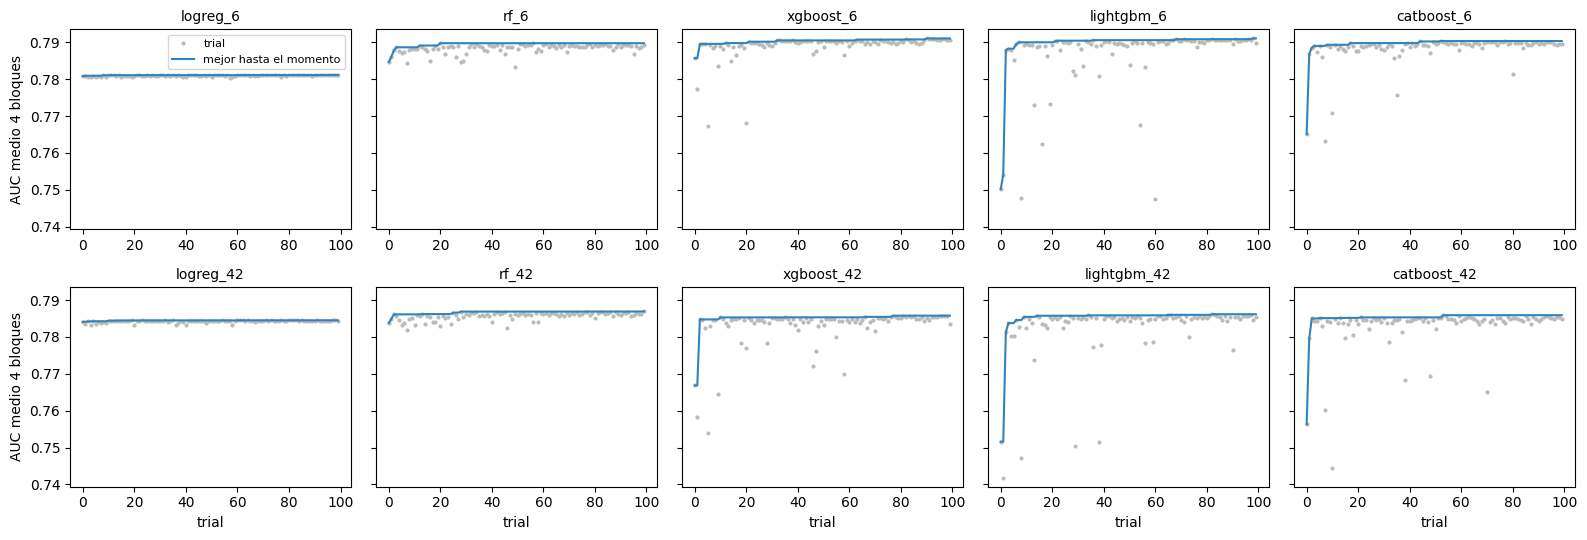

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(16, 5.5), sharey=True)
for ax, (key, e) in zip(axes.T.flat, EST.items()):
    v = pd.Series([t.value for t in e["study"].trials if t.value is not None])
    ax.plot(v, ".", c="#bbbbbb", ms=4, label="trial")
    ax.plot(v.cummax(), c="#3182bd", label="mejor hasta el momento")
    ax.set_title(key, fontsize=10)
axes[0, 0].legend(fontsize=8); axes[0, 0].set_ylabel("AUC medio 4 bloques"); axes[1, 0].set_ylabel("AUC medio 4 bloques")
for ax in axes[1]: ax.set_xlabel("trial")
plt.tight_layout(); plt.show()

## 3 · Conjunto de variables por algoritmo

Para cada algoritmo, 6 vs 42 con el criterio de selección (a igualdad gana el de menos variables).

In [5]:
rows, CAND = [], {}
for algo in tuning.ALGOS:
    sub = tun[tun.algo == algo]
    k = elegir(sub)
    CAND[algo] = EST[k]
    rows.append({"algoritmo": algo, "auc_6": sub.loc[f"{algo}_6", "auc"], "auc_42": sub.loc[f"{algo}_42", "auc"],
                 "lift_6": sub.loc[f"{algo}_6", "lift10"], "lift_42": sub.loc[f"{algo}_42", "lift10"],
                 "elegido": EST[k]["conjunto"]})
conj = pd.DataFrame(rows).set_index("algoritmo")
conj

,auc_6,auc_42,lift_6,lift_42,elegido
algoritmo,,,,,
logreg,0.7811,0.7845,2.192,2.267,42
rf,0.7898,0.7869,2.287,2.249,6
xgboost,0.7910,0.7858,2.281,2.272,6
lightgbm,0.7911,0.7862,2.312,2.293,6
catboost,0.7904,0.7859,2.281,2.296,6


## 4 · Ventanas de entrenamiento (§4.3)

Con los hiperparámetros y el conjunto ya fijados por algoritmo, se recorta el entrenamiento de cada bloque a los
últimos 24 / 36 / 48 meses o se usa toda la historia (ventana expansiva). La brecha de 6 meses se mantiene.

In [6]:
VENTANAS = {"24m": 24, "36m": 36, "48m": 48, "todo": None}
rows = []
for algo, c in CAND.items():
    c["ventanas"] = {}
    for vn, vm in VENTANAS.items():
        r = evaluacion.evaluar(tuning.make_model_factory(c["algo"], c["params"], SAMPLER), dev, c["feats"], folds,
                               ventana_meses=vm)
        c["ventanas"][vn] = r
        rows.append(fila(f"{algo}|{vn}", r, algo=algo, ventana=vn, n_vars=len(c["feats"])))
vent = pd.DataFrame(rows).set_index("config")
for algo, c in CAND.items():
    k = elegir(vent[vent.algo == algo])
    c["ventana"] = vent.loc[k, "ventana"]
    c["res_final"] = c["ventanas"][c["ventana"]]
    print(f"{algo:9s} -> ventana {c['ventana']:5s} auc={c['res_final']['auc']:.4f} lift10={c['res_final']['lift10']:.2f}")
vent_auc = vent.pivot(index="algo", columns="ventana", values="auc")[list(VENTANAS)]
vent_lift = vent.pivot(index="algo", columns="ventana", values="lift10")[list(VENTANAS)]
pd.concat({"auc": vent_auc, "lift10": vent_lift}, axis=1)

logreg    -> ventana 36m   auc=0.7871 lift10=2.24
rf        -> ventana todo  auc=0.7898 lift10=2.29
xgboost   -> ventana todo  auc=0.7910 lift10=2.28
lightgbm  -> ventana todo  auc=0.7911 lift10=2.31
catboost  -> ventana todo  auc=0.7904 lift10=2.28


auc                         lift10                     
ventana      24m     36m     48m    todo    24m    36m    48m   todo
algo                                                                
catboost  0.7871  0.7890  0.7902  0.7904  2.200  2.232  2.278  2.281
lightgbm  0.7884  0.7902  0.7904  0.7911  2.253  2.332  2.294  2.312
logreg    0.7866  0.7871  0.7859  0.7845  2.172  2.242  2.212  2.267
rf        0.7883  0.7892  0.7901  0.7898  2.298  2.260  2.239  2.287
xgboost   0.7885  0.7902  0.7898  0.7910  2.206  2.272  2.305  2.281

## 5 · Candidatos individuales y ensembles por promedio

Los 5 candidatos (uno por algoritmo, con su conjunto y ventana) se ordenan por AUC y se promedian sus
probabilidades OOF: top-2, top-3, top-4 y los cinco. Como cada bloque se predijo solo con historia previa, el
promedio de OOF equivale a entrenar el ensemble bloque a bloque. El criterio de selección decide entre todos.

In [7]:
ind = pd.DataFrame([fila(a, c["res_final"], n_vars=len(c["feats"]), n_miembros=1, ventana=c["ventana"])
                    for a, c in CAND.items()]).set_index("config")
orden = ind.sort_values(["auc", "lift10"], ascending=False).index.tolist()
ENS, rows = {}, []
for k in range(2, len(orden) + 1):
    miembros = orden[:k]
    oof = np.mean([CAND[a]["res_final"]["oof"] for a in miembros], axis=0)
    r = evaluacion.metricas_oof(dev, oof, folds)
    name = "+".join(miembros)
    ENS[name] = dict(miembros=miembros, res=r)
    rows.append(fila(name, r, n_vars=len(set().union(*[CAND[a]["feats"] for a in miembros])),
                     n_miembros=k, ventana="por miembro"))
cand = pd.concat([ind, pd.DataFrame(rows).set_index("config")])
FINAL = elegir(cand)
print(f"-> modelo final: {FINAL}  auc={cand.loc[FINAL, 'auc']:.4f}  lift10={cand.loc[FINAL, 'lift10']:.2f}")
cand.sort_values(["auc", "lift10"], ascending=False)

-> modelo final: lightgbm+xgboost+catboost  auc=0.7912  lift10=2.34


,auc_b1,auc_b2,auc_b3,auc_b4,auc,std,lift10,n_vars,n_miembros,ventana
config,,,,,,,,,,
lightgbm+xgboost+catboost+rf+logreg,0.7999,0.7846,0.8007,0.7828,0.7920,0.0083,2.311,42,5,por miembro
lightgbm+xgboost,0.8004,0.7848,0.7995,0.7803,0.7913,0.0088,2.300,6,2,por miembro
lightgbm+xgboost+catboost,0.8001,0.7846,0.7999,0.7803,0.7912,0.0089,2.344,6,3,por miembro
lightgbm+xgboost+catboost+rf,0.7995,0.7845,0.7999,0.7803,0.7911,0.0088,2.315,6,4,por miembro
lightgbm,0.7994,0.7847,0.7993,0.7808,0.7911,0.0084,2.312,6,1,todo
xgboost,0.8011,0.7845,0.7994,0.7792,0.7910,0.0094,2.281,6,1,todo
catboost,0.7984,0.7836,0.8001,0.7793,0.7904,0.0090,2.281,6,1,todo
rf,0.7973,0.7836,0.7990,0.7790,0.7898,0.0086,2.287,6,1,todo
logreg,0.7928,0.7776,0.7960,0.7819,0.7871,0.0076,2.242,42,1,36m


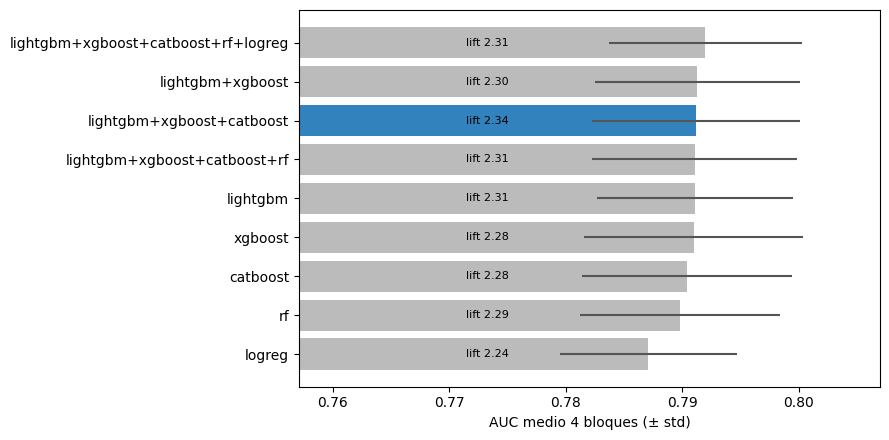

In [8]:
c = cand.sort_values("auc")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(c.index, c.auc, xerr=c["std"], color=np.where(c.index == FINAL, "#3182bd", "#bbbbbb"), ecolor="#555")
for i, (a, l) in enumerate(zip(c.auc, c.lift10)):
    ax.text(c.auc.min() - 0.012, i, f"lift {l:.2f}", va="center", ha="right", fontsize=8)
ax.set_xlim(c.auc.min() - 0.03, c.auc.max() + 0.015); ax.set_xlabel("AUC medio 4 bloques (± std)")
plt.tight_layout(); plt.show()

## 6 · Exportación

`modelo_final.json` deja todo lo necesario para que `05_evaluacion` entrene la configuración final con todo el pool
de desarrollo y la evalúe una sola vez en el OOT. `reports/modelado.md` resume los números.

In [9]:
def spec_cand(a):
    c = CAND[a]
    return {"algoritmo": c["algo"], "conjunto": c["conjunto"], "variables": c["feats"], "params": c["params"],
            "ventana": c["ventana"], "ventana_meses": VENTANAS[c["ventana"]],
            "auc": c["res_final"]["auc"], "aucs": c["res_final"]["aucs"], "lift10": c["res_final"]["lift10"]}

miembros_final = ENS[FINAL]["miembros"] if FINAL in ENS else [FINAL]
spec = {"fecha": pd.Timestamp.today().strftime("%Y-%m-%d"), "n_trials": N_TRIALS,
        "criterio": f"AUC medio 4 bloques; empate (<= {TOL_AUC}) por lift top-10 % mensual; empate (<= {TOL_LIFT}) el más simple",
        "desbalance": DESBALANCE,
        "candidatos": {a: spec_cand(a) for a in CAND},
        "ensembles": {n: {"miembros": e["miembros"], "auc": e["res"]["auc"], "aucs": e["res"]["aucs"],
                          "lift10": e["res"]["lift10"]} for n, e in ENS.items()},
        "final": {"config": FINAL, "tipo": "ensemble" if FINAL in ENS else "individual", "miembros": miembros_final,
                  "auc": float(cand.loc[FINAL, "auc"]), "lift10": float(cand.loc[FINAL, "lift10"]),
                  "n_vars": int(cand.loc[FINAL, "n_vars"])}}
(Path.cwd() / "modelo_final.json").write_text(json.dumps(spec, indent=2, ensure_ascii=False, default=float))

tun_md = tun[["algo", "n_vars", "auc_b1", "auc_b2", "auc_b3", "auc_b4", "auc", "std", "lift10", "best_trial"]]
cand_md = cand.sort_values(["auc", "lift10"], ascending=False)[
    ["n_miembros", "n_vars", "ventana", "auc_b1", "auc_b2", "auc_b3", "auc_b4", "auc", "std", "lift10"]]
texto = f"""# Modelado (sem2)

Generado por `04_modelado/modelado.ipynb`. Pool de desarrollo: {len(dev):,} filas; 4 bloques de validación temporal
(`02_particion/particion.json`). Criterio: {spec["criterio"]}.

## 1 · Desbalance (§4.1) — XGBoost de referencia, 6 variables
{desb.round(4).to_markdown()}

**Elegido: {DESBALANCE}.**

## 2 · Optuna (§4.3) — {N_TRIALS} trials por estudio, objetivo AUC medio, peso de clase en el espacio de búsqueda
{tun_md.round(4).to_markdown()}

## 3 · Conjunto de variables por algoritmo
{conj.round(4).to_markdown()}

## 4 · Ventanas de entrenamiento (hiperparámetros fijos)
AUC medio:
{vent_auc.round(4).to_markdown()}

Lift top-10 % mensual:
{vent_lift.round(3).to_markdown()}

Ventana elegida: {", ".join(f"{a} → {c['ventana']}" for a, c in CAND.items())}.

## 5 · Candidatos individuales y ensembles por promedio
{cand_md.round(4).to_markdown()}

## Modelo final
**{FINAL}** ({spec["final"]["tipo"]}, {spec["final"]["n_vars"]} variables): AUC medio {spec["final"]["auc"]:.4f},
lift top-10 % mensual {spec["final"]["lift10"]:.2f}.

Hiperparámetros de los miembros:
""" + "\n".join(f"- `{a}` ({CAND[a]['conjunto']} vars, ventana {CAND[a]['ventana']}): `{CAND[a]['params']}`"
                for a in miembros_final) + """

Lectura: todas las métricas son de selección (los mismos bloques se usan para decidir); la estimación final es la
del OOT en `05_evaluacion`.
"""
(datos.ROOT / "reports" / "modelado.md").write_text(texto)
print("-> modelo_final.json, trials/*.csv, reports/modelado.md")

-> modelo_final.json, trials/*.csv, reports/modelado.md
